# DEVELOPMENT OF A CNN-BASED YOLOv8 MODEL FOR POTHOLE DETECTION, SEVERITY ASSESSMENT AND REPAIR PRIORITISATION ON ROADS IN KAMPALA 
**Notebook**
**UTAMU, MSc Computing, Oct 2026**
**Author:** *(NKURUNUNGI EDISON) (JAN22/COMP/959U)*  
**Study area:** 5 km segment of the Kireka-Kamuli Road  
**Pipeline (proposal, Section 2.3):** **Pipeline:** Roboflow annotation (bounding boxes with severity classes) → Roboflow preprocessing (auto-orient, resize to 512x512) and YOLOv8 export → YOLOv8 fine-tuned from COCO weights in Google Colab → evaluation on a held-out test set (mAP@0.5, mAP@0.5:0.95, precision, recall, F1)

## Before you run
This notebook needs the **Roboflow export in YOLOv8 format** (a folder with `train/`, `valid/`, `test/`, each containing `images/` and `labels/`, plus `data.yaml`). The labels must be bounding boxes with severity classes (mild, moderate, severe), as defined in Appendix 3 of the proposal. Image-level labels (pothole / normal) are not enough for YOLOv8.

**Run on a GPU** (Google Colab, as in Section 3.6 of the proposal).

## 1. Setup

In [ ]:
!pip install -q ultralytics
import os, glob, yaml, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import torch
print("GPU available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 10.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
GPU available: True


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="123456789000000")
project = rf.workspace("magala-muhsin-s-workspace").project("kmr")
version = project.version(1)
dataset = version.download("yolov8")

import os, yaml
DATA_DIR = dataset.location
MODEL = "yolov8m.pt"
EPOCHS = 100
IMGSZ = 512
BATCH = 16
SEED = 42

with open(os.path.join(DATA_DIR, "data.yaml")) as f:
    cfg = yaml.safe_load(f)
cfg["path"] = os.path.abspath(DATA_DIR)
cfg["train"] = "train/images"
cfg["val"] = "valid/images"
cfg["test"] = "test/images"
DATA_YAML = os.path.join(DATA_DIR, "data_abs.yaml")
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(cfg, f)
names = cfg["names"] if isinstance(cfg["names"], list) else [cfg["names"][k] for k in sorted(cfg["names"])]
print("Classes:", names)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to KMR-1 in yolov8:: 100%|██████████| 1005/1005 [00:00<00:00, 8727.93it/s]

Classes: ['mild', 'moderate', 'severe']


## 2. Dataset summary

train  images:  355 | boxes:  569 | per class: {'mild': np.int64(160), 'moderate': np.int64(258), 'severe': np.int64(151)}
valid  images:   73 | boxes:  130 | per class: {'mild': np.int64(46), 'moderate': np.int64(50), 'severe': np.int64(34)}
test   images:   72 | boxes:  122 | per class: {'mild': np.int64(37), 'moderate': np.int64(49), 'severe': np.int64(36)}


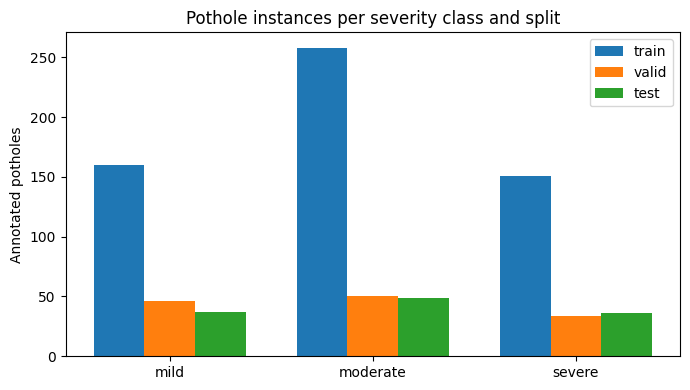

In [ ]:
rows = []
inst = {}
for split in ["train", "valid", "test"]:
    imgs = glob.glob(os.path.join(DATA_DIR, split, "images", "*"))
    cnt = np.zeros(len(names), dtype=int)
    for lf in glob.glob(os.path.join(DATA_DIR, split, "labels", "*.txt")):
        for line in open(lf):
            p = line.split()
            if p:
                cnt[int(float(p[0]))] += 1
    inst[split] = cnt
    rows.append((split, len(imgs), int(cnt.sum())))
    print(f"{split:6s} images: {len(imgs):4d} | boxes: {cnt.sum():4d} | per class: {dict(zip(names, cnt))}")

# Figure: instances per class and split
x = np.arange(len(names)); w = 0.25
plt.figure(figsize=(7, 4))
for k, split in enumerate(["train", "valid", "test"]):
    plt.bar(x + (k - 1) * w, inst[split], w, label=split)
plt.xticks(x, names)
plt.ylabel("Annotated potholes")
plt.title("Pothole instances per severity class and split")
plt.legend()
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/dataset_instances.png", dpi=200)
plt.show()

## 3. Training
YOLOv8 is fine-tuned from COCO-pretrained weights (transfer learning). No Roboflow augmentation was applied (Roboflow was used only for auto-orientation and resizing to 512x512) YOLOv8 also applies its built-in mosaic augmentation during training. Early stopping (`patience=20`) prevents overfitting on the small dataset.

In [ ]:
model = YOLO(MODEL)
train_results = model.train(
    data=DATA_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, seed=SEED,
    patience=20, project="runs_pothole", name="yolov8_kampala", exist_ok=True,
    device=0 if torch.cuda.is_available() else "cpu",
)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/KMR-1/data_abs.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_kampala, nbs=64, nms=None, opset=None, optimize=False

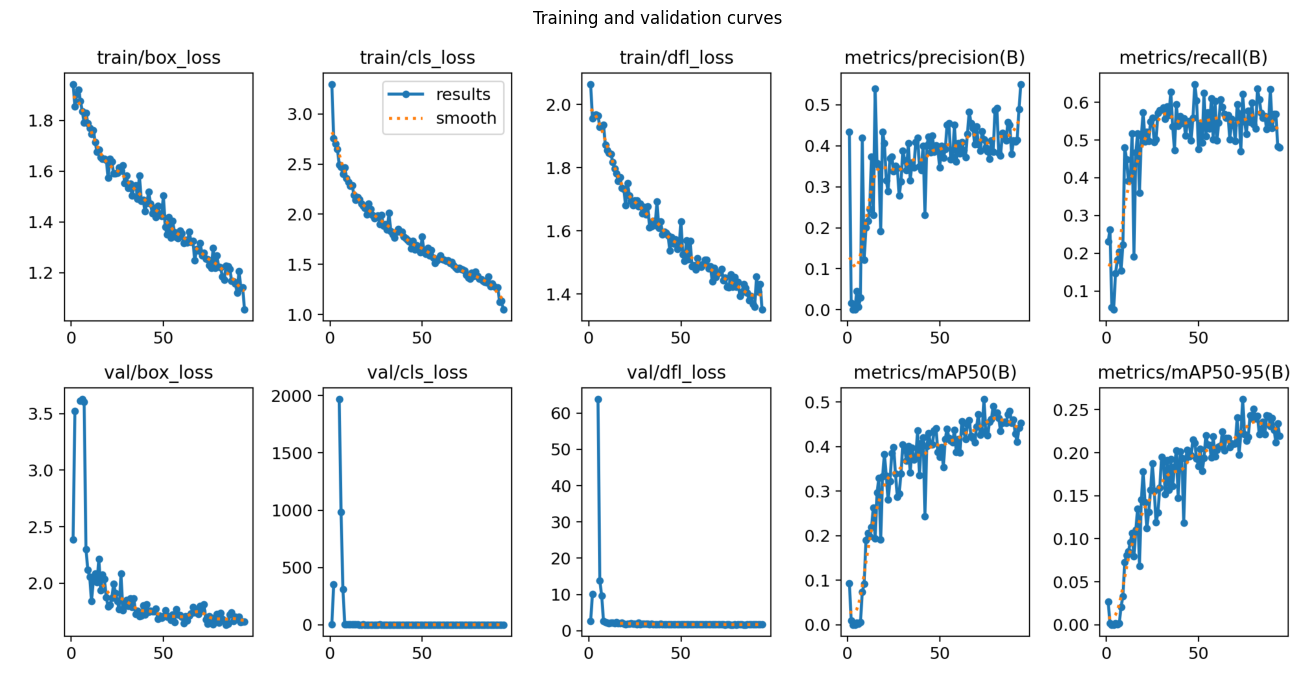

In [ ]:
run_dir = "/content/runs/detect/runs_pothole/yolov8_kampala"
img = Image.open(os.path.join(run_dir, "results.png"))
plt.figure(figsize=(14, 7)); plt.imshow(img); plt.axis("off"); plt.title("Training and validation curves")
plt.tight_layout(); plt.show()

## 4. Evaluation on the held-out test set

In [ ]:
best = YOLO(os.path.join(run_dir, "weights", "best.pt"))
m = best.val(data=DATA_YAML, split="test", imgsz=IMGSZ, project="runs_pothole", name="test_eval", exist_ok=True)

P, R = float(m.box.mp), float(m.box.mr)
F1 = 2 * P * R / (P + R + 1e-9)
print(f"mAP@0.5      : {m.box.map50:.3f}")
print(f"mAP@0.5:0.95 : {m.box.map:.3f}")
print(f"Precision    : {P:.3f}")
print(f"Recall       : {R:.3f}")
print(f"F1-score     : {F1:.3f}")

print("\nPer-class results")
print(f"{'class':10s} {'P':>6s} {'R':>6s} {'F1':>6s} {'mAP50':>7s} {'mAP50-95':>9s}")
for j, ci in enumerate(m.box.ap_class_index):
    print(f"{names[ci]:10s} {m.box.p[j]:6.3f} {m.box.r[j]:6.3f} {m.box.f1[j]:6.3f} {m.box.ap50[j]:7.3f} {m.box.ap[j]:9.3f}")

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 17.9±15.1 MB/s, size: 50.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/KMR-1/test/labels... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 331.5it/s 0.2s
val: New cache created: /content/KMR-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.1s
                   all         72        122      0.475      0.601      0.463      0.219
                  mild         25         37      0.499      0.511      0.404       0.12
              moderate         42         49      0.454      0.735      0.488      0.271
                severe       

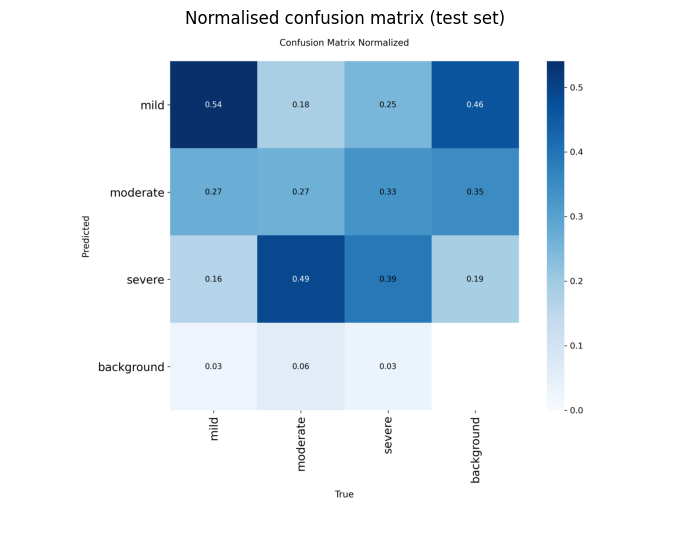

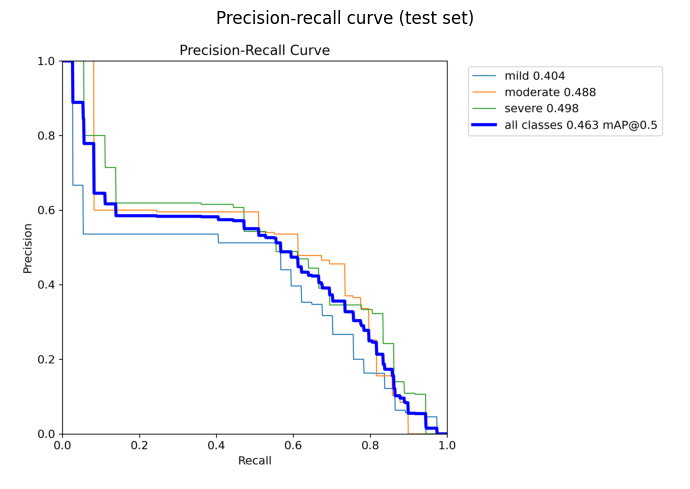

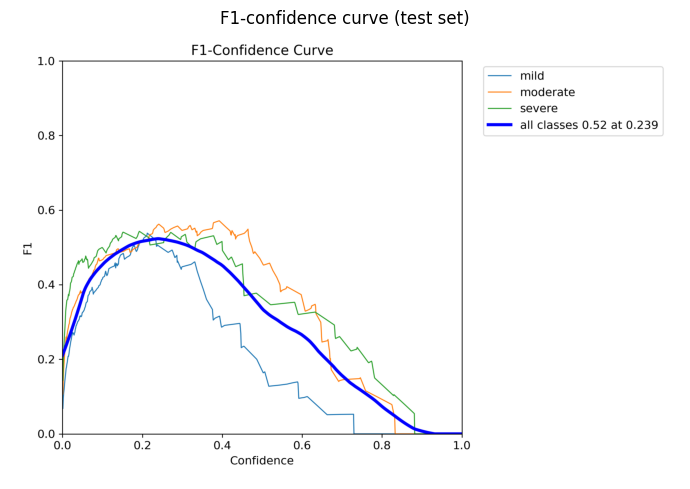

In [ ]:
# Confusion matrix and PR curve (generated by Ultralytics on the test set)
ev = str(m.save_dir)
for fn, title in [("confusion_matrix_normalized.png", "Normalised confusion matrix (test set)"),
                  ("BoxPR_curve.png", "Precision-recall curve (test set)"),
                  ("BoxF1_curve.png", "F1-confidence curve (test set)")]:
    p = os.path.join(ev, fn)
    if os.path.exists(p):
        plt.figure(figsize=(7, 6)); plt.imshow(Image.open(p)); plt.axis("off"); plt.title(title)
        plt.tight_layout(); plt.show()

## 5. Qualitative results

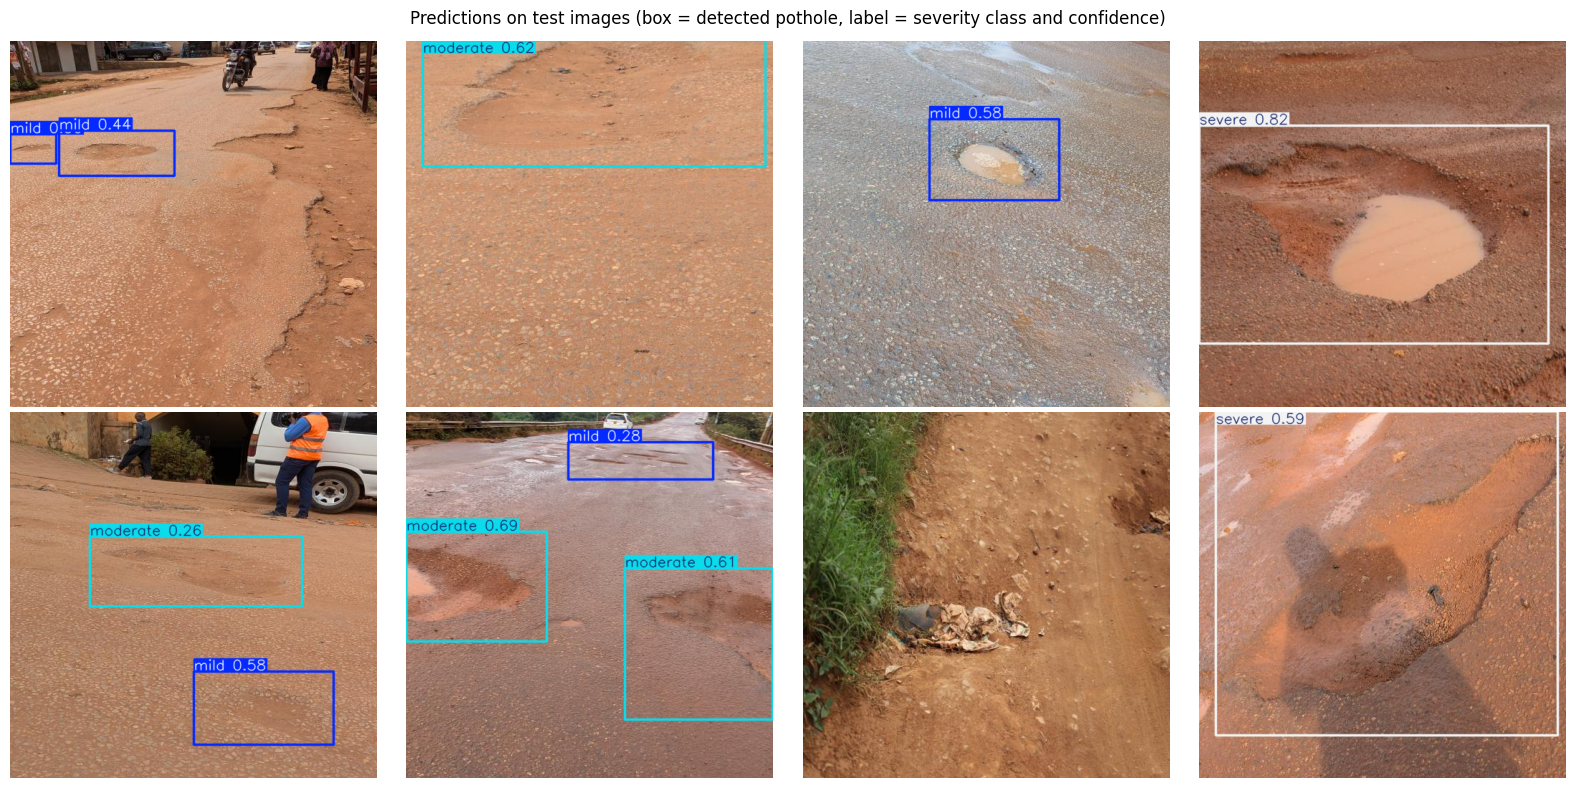

In [ ]:
test_imgs = sorted(glob.glob(os.path.join(DATA_DIR, "test", "images", "*")))
rng = np.random.RandomState(0)
pick = rng.choice(test_imgs, min(8, len(test_imgs)), replace=False)
res = best.predict(list(pick), imgsz=IMGSZ, conf=0.25, verbose=False)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax in axes.ravel():
    ax.axis("off")
for ax, r in zip(axes.ravel(), res):
    ax.imshow(r.plot()[:, :, ::-1])
plt.suptitle("Predictions on test images (box = detected pothole, label = severity class and confidence)")
plt.tight_layout()
plt.savefig("figures/test_predictions.png", dpi=200)
plt.show()

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("pothole_results", "zip", "/content/runs/detect/runs_pothole")
files.download("pothole_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()
print(list(uploaded.keys()))

Saving IMG_0465.JPG to IMG_0465.JPG
Saving IMG_0466.JPG to IMG_0466.JPG
['IMG_0465.JPG', 'IMG_0466.JPG']


IMG_0465.JPG -> detections: 4
   moderate 0.8
   moderate 0.55
   mild 0.42
   mild 0.27


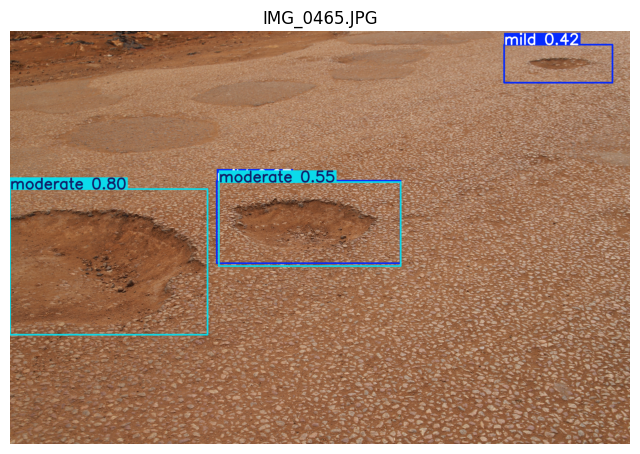

IMG_0466.JPG -> detections: 1
   moderate 0.79


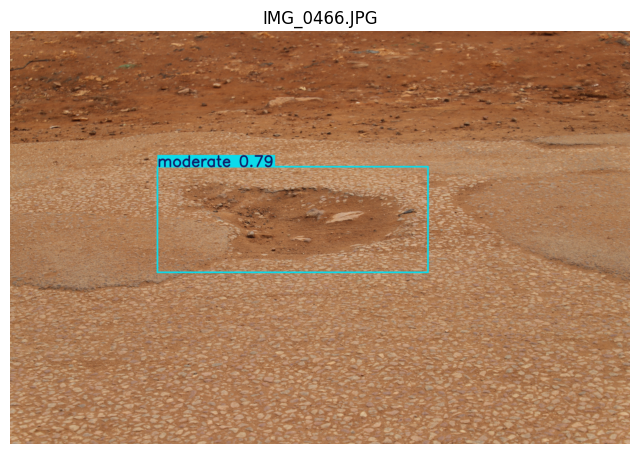

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("/content/runs/detect/runs_pothole/yolov8_kampala/weights/best.pt")

for name in ["IMG_0465.JPG", "IMG_0466.JPG"]:
    r = model.predict(name, conf=0.25, imgsz=512, verbose=False)[0]
    print(name, "-> detections:", len(r.boxes))
    for b in r.boxes:
        print("  ", r.names[int(b.cls)], round(float(b.conf), 2))
    plt.figure(figsize=(8, 6))
    plt.imshow(r.plot()[:, :, ::-1])
    plt.axis("off")
    plt.title(name)
    plt.show()

**Observations.**
 The fine-tuned YOLOv8m model reached mAP@0.5 of 0.463 and mAP@0.5:0.95 of 0.219 on the held-out test set (72 images, 122 annotated potholes), with precision 0.475, recall 0.601 and F1 0.530. The confusion matrix (confidence 0.25) shows that the model rarely missed a pothole altogether (3% to 6% of instances), so the main weakness is severity assignment and not detection. Only 54% of mild, 27% of moderate and 39% of severe potholes were assigned their correct class. Moderate potholes were most often predicted as severe (49%), and severe potholes were spread across mild (25%) and moderate (33%), which indicates that the boundaries between severity classes were not learned consistently. This is consistent with the limitation that severity labels were assigned by visual judgement and not measured depth or volume. Mild potholes had the lowest localisation quality (mAP@0.5:0.95 of 0.120), likely because they are shallow and their edges are hard to delineate. Test performance was lower than validation performance (mAP@0.5 of 0.463 against 0.508), which is expected with a dataset of this size. The results are a baseline for Kampala road imagery and not a deployable system.

## 6. Answering the research questions
1. **Dataset collection and annotation:** state the number of images and the number of boxes per class from Section 2.
2. **Effect of transfer learning and augmentation:** compare the training curves with the final test metrics.
3. **Performance:** report mAP@0.5, mAP@0.5:0.95, precision, recall and F1 from Section 4.
4. **Variation across classes and conditions:** use the per-class table, and the lighting, weather and surface notes from your collection log.

## 7. Limitations (from Section 1.11 of the proposal)
- Single 5 km segment of the Northern Bypass, so generalisability to other roads and cities needs further validation.
- Modest dataset size (300 to 500 images), mitigated by transfer learning and augmentation.
- Severity labels are based on visual judgement (Appendix 3 rubric), not measured depth or volume.
- Test-set performance only. The model is not deployed in a live KCCA workflow.
- Mostly dry-season daylight images, so performance in heavy rain, dust or low light is not fully characterised.
- Small test split: per-class metrics, especially for the rarest severity class, can change a lot with a few images.